### This notebook looks into the convergence of weights in each cerebellar voxel in NNLS and Ridge

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.summarize as ccs
import Functional_Fusion.atlas_map as am
import SUITPy as suit

#### Load models

In [2]:
ds_code = gl.traindata_string()
ext1 = "A0_global"
ext2 = "A2_global"

NNLS_mo, _ = ccs.get_model(ds_code, 'Icosahedron1002', 'NNLS', ext1, cerebellum_atlas='MNISymC3', norm=True)
L2reg_mo, _ = ccs.get_model(ds_code, 'Icosahedron1002', 'L2reg', ext2, cerebellum_atlas='MNISymC3', norm=True)

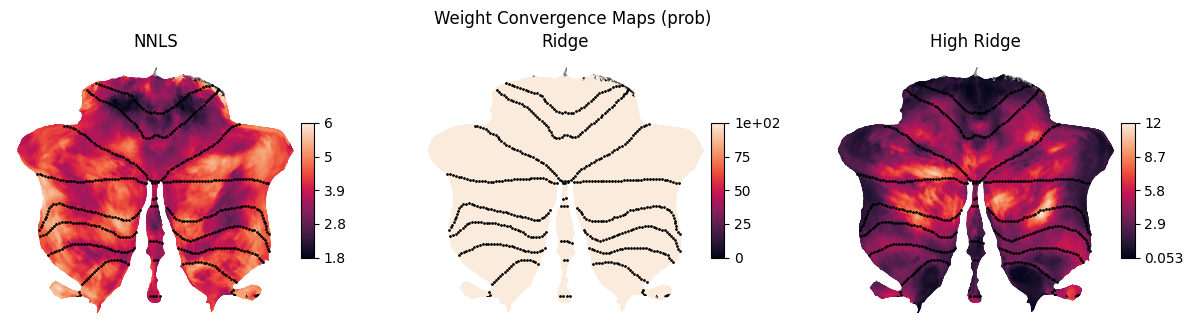

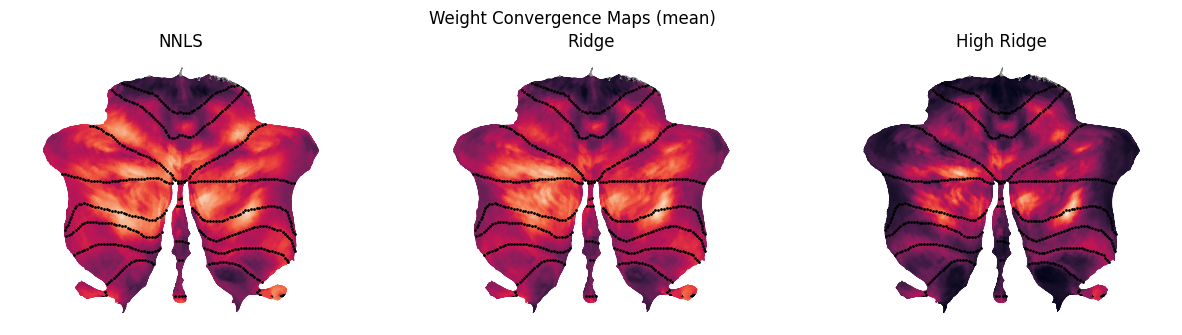

In [3]:
atlas, _ = am.get_atlas('MNISymC3')
conv_types = ['prob', 'mean']
threshold = 1e-8

# alter Ridge coefficients
Ridge_high_coef = np.where(L2reg_mo.coef_ >= np.percentile(L2reg_mo.coef_, 96), L2reg_mo.coef_, 0)
Ridge_coef = L2reg_mo.coef_
NNLS_coef = NNLS_mo.coef_

for conv_type in conv_types:
    if conv_type == 'prob':
        conv_NNLS = np.nanmean(NNLS_coef > threshold, axis=1) * 100
        conv_Ridge = np.nanmean(np.abs(Ridge_coef) > threshold, axis=1) * 100
        conv_high_Ridge = np.nanmean(Ridge_high_coef > threshold, axis=1) * 100
        colorbar = True
    elif conv_type == 'mean':
        conv_NNLS = np.nanmean(NNLS_coef, axis=1)
        conv_Ridge = np.nanmean(np.abs(Ridge_coef), axis=1)
        conv_high_Ridge = np.nanmean(Ridge_high_coef, axis=1)
        colorbar = False

    fig, axs = plt.subplots(1, 3, figsize=(15, 3.5))
    plt.suptitle(f'Weight Convergence Maps ({conv_type})', y=1.01)
    plt.subplot(1,3,1)
    plt.title(f'NNLS')
    vox_data = suit.vol_to_surf(atlas.data_to_nifti(conv_NNLS), space='MNISymC')
    suit.flatmap.plot(vox_data, cmap='rocket', colorbar=colorbar, new_figure=False);
    plt.subplot(1,3,2)
    plt.title(f'Ridge')
    vox_data = suit.vol_to_surf(atlas.data_to_nifti(conv_Ridge), space='MNISymC')
    if conv_type == 'prob':
        suit.flatmap.plot(vox_data, cmap='rocket', colorbar=colorbar, new_figure=False, cscale=[0, 100]);
    else:
        suit.flatmap.plot(vox_data, cmap='rocket', colorbar=colorbar, new_figure=False);
    plt.subplot(1,3,3)
    plt.title(f'High Ridge')
    vox_data = suit.vol_to_surf(atlas.data_to_nifti(conv_high_Ridge), space='MNISymC')
    suit.flatmap.plot(vox_data, cmap='rocket', colorbar=colorbar, new_figure=False);
    plt.show()